/tmp/ipykernel_282/2620582201.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('TCS.NS', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Shape: (1238, 5)

First 5 rows:
Price             Close         High          Low         Open   Volume
Ticker           TCS.NS       TCS.NS       TCS.NS       TCS.NS   TCS.NS
Date                                                                   
2020-01-01  1866.113403  1880.146104  1854.404913  1866.457684  1354908
2020-01-02  1857.547607  1876.745997  1850.272939  1876.745997  2380752
2020-01-03  1894.567017  1913.808495  1863.014657  1863.014657  4655761
2020-01-06  1894.394409  1916.347673  1883.589918  1898.311602  3023209
2020-01-07  1899.044312  1906.620175  1880.061145  1894.438345  2429317


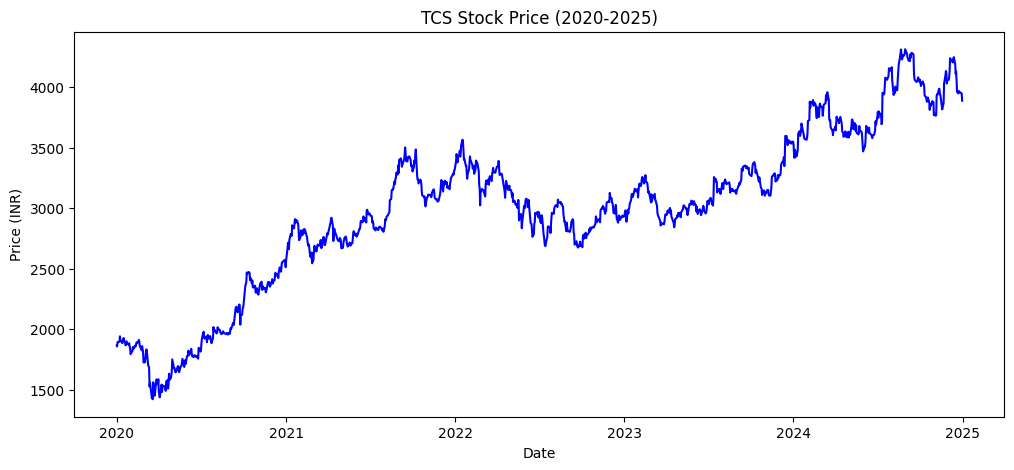

In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = yf.download('TCS.NS', start='2020-01-01', end='2025-01-01')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

plt.figure(figsize=(12,5))
plt.plot(df['Close'], color='blue')
plt.title('TCS Stock Price (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.show()

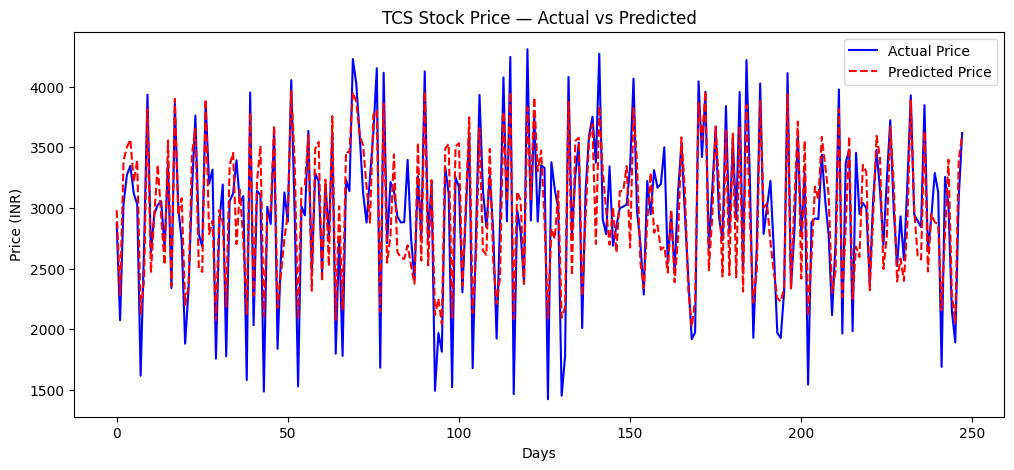

✅ Model Accuracy Score: 77.65%


In [ ]:
df['Days'] = np.arange(len(df))

X = df[['Days']].values
y = df['Close'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

plt.figure(figsize=(12,5))
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red', linestyle='--')
plt.title('TCS Stock Price — Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

score = model.score(X_test, y_test)
print(f"✅ Model Accuracy Score: {round(score*100, 2)}%")

In [ ]:
future_days = np.arange(len(df), len(df) + 30).reshape(-1, 1)
future_prices = model.predict(future_days)

print("📈 TCS Predicted Prices for Next 30 Days:")
for i in range(len(future_prices)):
    print(f"Day {i+1}: ₹{round(future_prices[i][0], 2)}")

📈 TCS Predicted Prices for Next 30 Days:
Day 1: ₹3974.44
Day 2: ₹3976.03
Day 3: ₹3977.62
Day 4: ₹3979.22
Day 5: ₹3980.81
Day 6: ₹3982.4
Day 7: ₹3983.99
Day 8: ₹3985.58
Day 9: ₹3987.17
Day 10: ₹3988.76
Day 11: ₹3990.35
Day 12: ₹3991.94
Day 13: ₹3993.53
Day 14: ₹3995.12
Day 15: ₹3996.71
Day 16: ₹3998.3
Day 17: ₹3999.9
Day 18: ₹4001.49
Day 19: ₹4003.08
Day 20: ₹4004.67
Day 21: ₹4006.26
Day 22: ₹4007.85
Day 23: ₹4009.44
Day 24: ₹4011.03
Day 25: ₹4012.62
Day 26: ₹4014.21
Day 27: ₹4015.8
Day 28: ₹4017.39
Day 29: ₹4018.99
Day 30: ₹4020.58
